# **CHURN PREDICTION**

This notebook analyzes customer churn (attrition) in a bank-card customer dataset. The analysis moves from data understanding and visualization to preprocessing, model training, and comparison of classification models.

## **Business Context**

The business goal is to identify customers who are likely to leave the bank so that the bank can contact them early with relevant retention actions. A useful model should detect attrited customers while avoiding too many false alarms.

## **Objective**

The objective is to predict `Attrition_Flag`: 0 represents an existing customer and 1 represents an attrited customer. The analysis will identify patterns associated with churn and compare classification models using accuracy, precision, recall, and F1-score.

## **Data Description**

The dataset contains customer demographics, account information, transaction behavior, and the target churn label. These variables allow us to study both who the customers are and how they use their accounts before predicting attrition.

# **INSTALLING AND IMPORTING LIBRARIES**

The required Python libraries are installed and imported for data manipulation, visualization, preprocessing, model training, and evaluation. Scikit-learn supplies the classification algorithms and evaluation metrics used later.

In [2]:
!pip install matplotlib seaborn scikit-learn pandas

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.tree import plot_tree

# **LOADING THE DATASET**

The CSV file is loaded into a pandas DataFrame named `data`. All later summaries, charts, preprocessing steps, and models use this DataFrame.

In [4]:
data=pd.read_csv("C:/Users/ushan/Downloads/Churn Prediction (1).csv")

 # **DATA OVERVIEW**

Data Overview is done to understand the basic structure and quality of the dataset:
-Number of rows and columns using (data.shape)
-Column names and data types
-Summary statistics such as mean, minimum, maximum, and quartiles
-Categorical and numerical variables
-Possible missing values or unusual values


The shape gives the number of observations and variables. A large number of rows provides more examples for training, while the number of columns indicates how many customer characteristics are available before preprocessing.

In [5]:
data.shape

(10127, 21)

This summary shows central tendency and spread for the numerical variables. Compare the mean with the median and inspect the minimum and maximum values to notice skewness, unusual ranges, or possible outliers.

In [6]:
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


The transposed summary makes it easier to compare statistics feature by feature. Each row represents one numerical variable, so the quartiles and range can be inspected without scrolling across many columns.

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


`data.info` is a method reference; use `data.info()` to display column types, non-null counts, and memory usage. The non-null counts are important for deciding whether missing-value treatment is required.

In [8]:
data.info

<bound method DataFrame.info of        CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      768805383  Existing Customer            45      M                3   
1      818770008  Existing Customer            49      F                5   
2      713982108  Existing Customer            51      M                3   
3      769911858  Existing Customer            40      F                4   
4      709106358  Existing Customer            40      M                3   
...          ...                ...           ...    ...              ...   
10122  772366833  Existing Customer            50      M                2   
10123  710638233  Attrited Customer            41      M                2   
10124  716506083  Attrited Customer            44      F                1   
10125  717406983  Attrited Customer            30      M                2   
10126  714337233  Attrited Customer            43      F                2   

      Education_Level Marital_Status Income

This repeated summary confirms the numerical ranges before visualization. Variables measured on very different scales, such as credit limit and utilization ratio, may need scaling for some algorithms, although tree-based models are generally insensitive to feature scale.

In [9]:
data.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


The columns are grouped by their role in analysis: categorical columns describe customer groups or discrete counts, while numerical columns contain continuous measurements. This grouping determines whether countplots, boxplots, or encoding steps are appropriate.

In [10]:
cat_columns= ['Attrition_Flag','Gender','Education_Level','Marital_Status','Income_Category'
              ,'Card_Category','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon',
              'Dependent_count']
num_columns=['Customer_Age','Months_on_book','Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy',
             'Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Avg_Utilization_Ratio']


## **UNIVARIATE ANALYSIS**

“Uni” means one. Univariate analysis studies one variable at a time.

-Countplots for categorical columns such as Gender and Education_Level
-Boxplots for numerical columns such as Customer_Age and Credit_Limit

Purpose:

-Understand the distribution of each feature
-See the most common categories
-Identify unusual values and outliers
-Check whether numerical data is spread evenly or skewed
-Understand the dataset before comparing variables


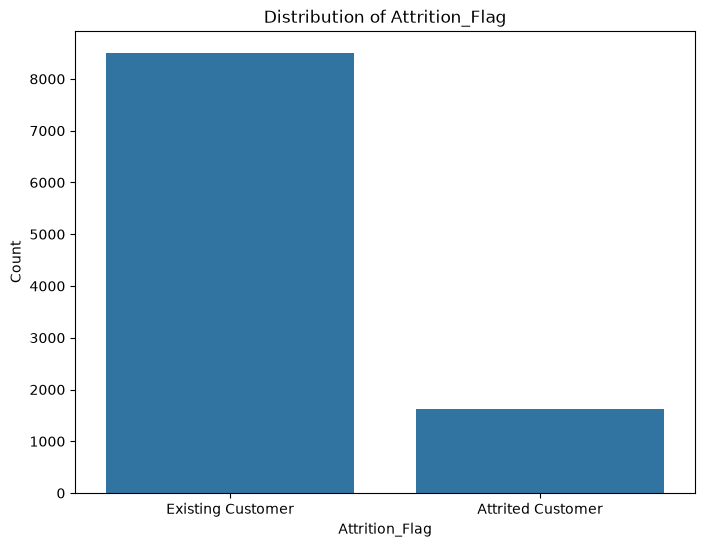

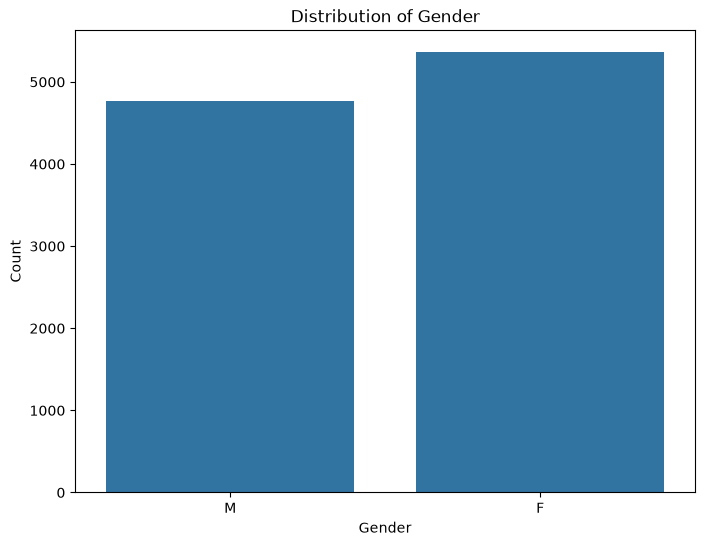

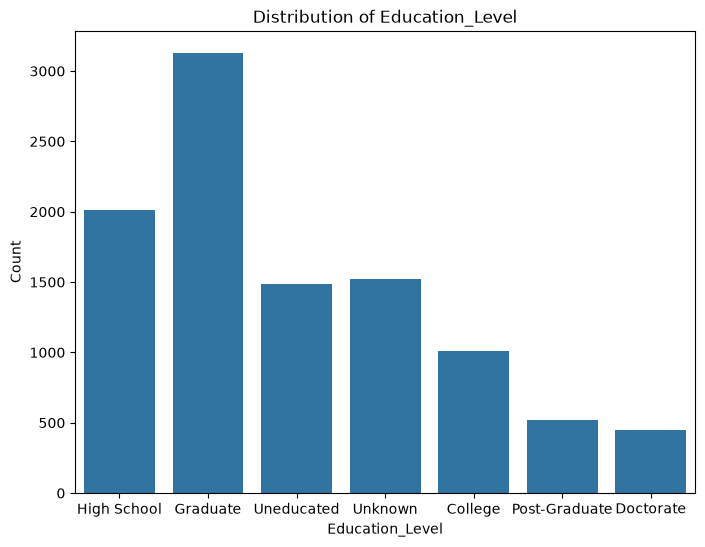

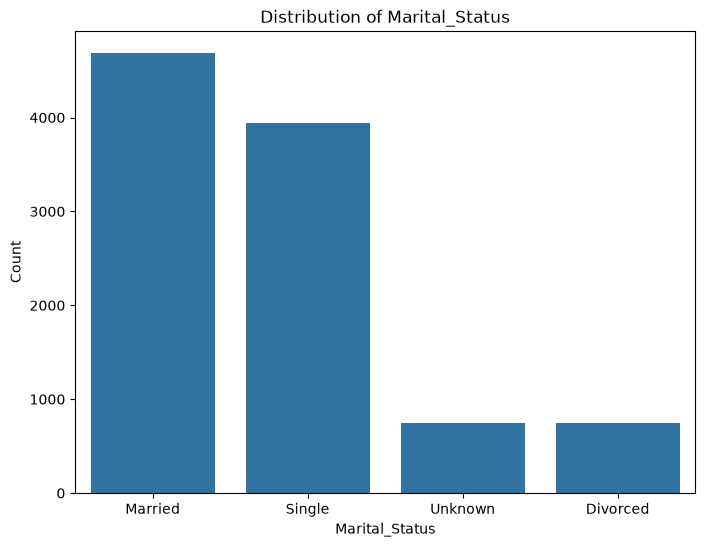

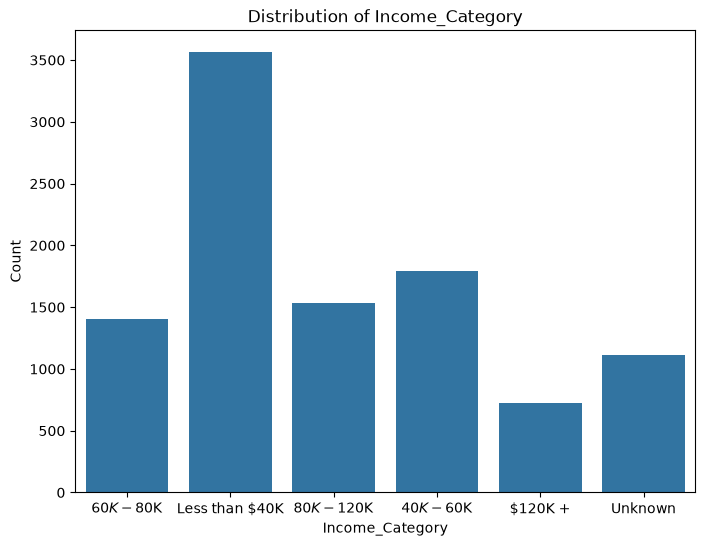

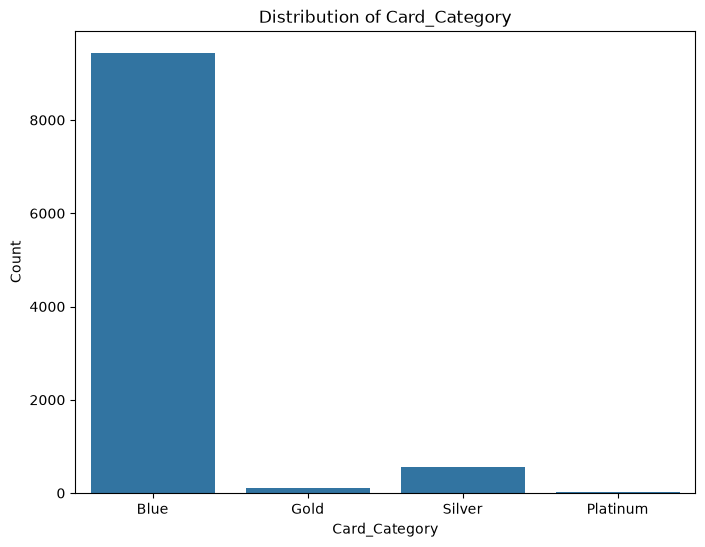

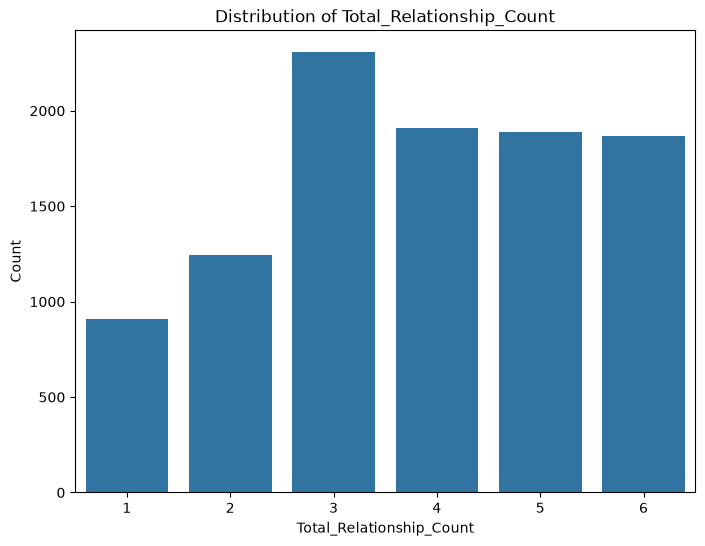

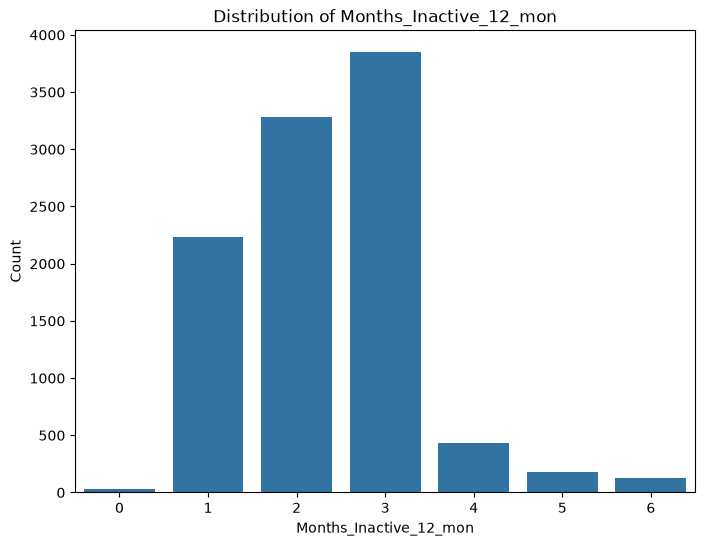

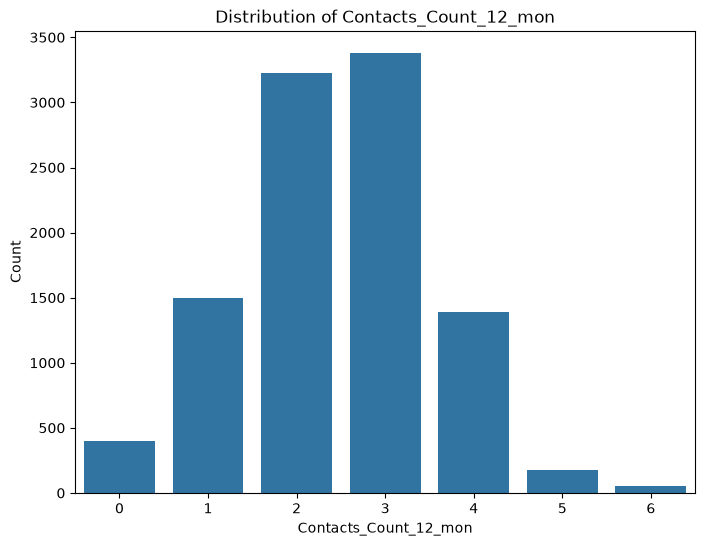

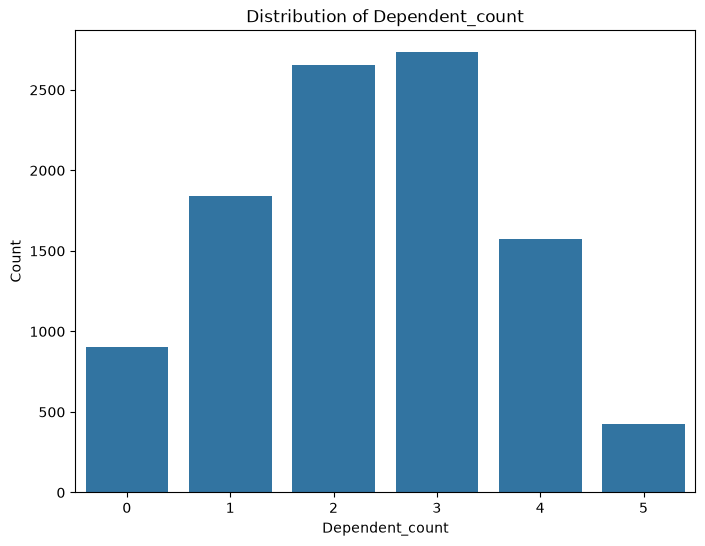

In [11]:
for col in cat_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(x=col, data=data)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

The countplots show how customers are distributed across each categorical variable. Look for dominant categories and categories with very few observations, because highly uneven groups can affect both interpretation and model performance.

In [12]:
data.describe()


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


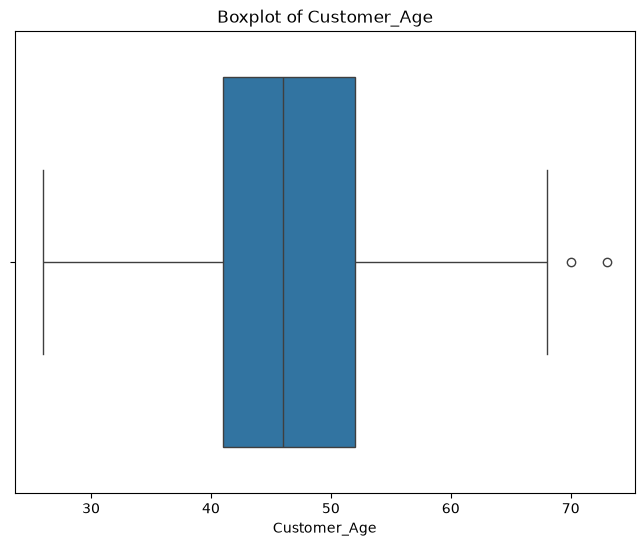

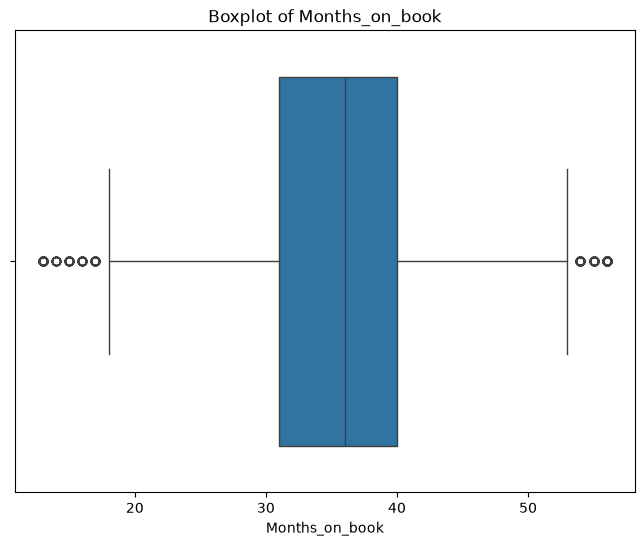

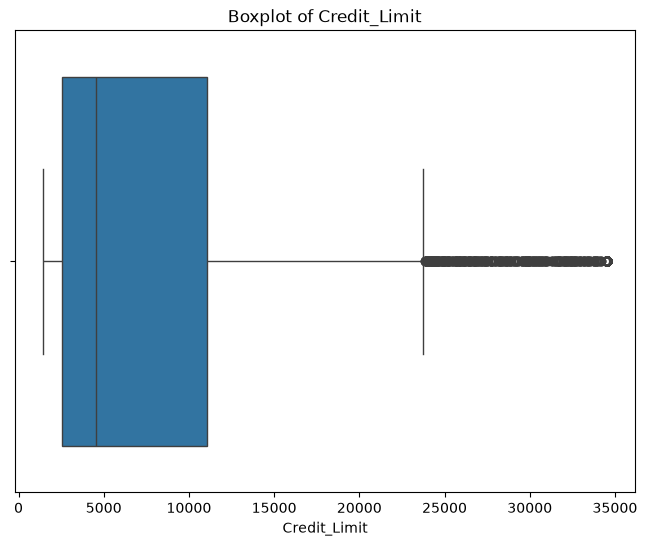

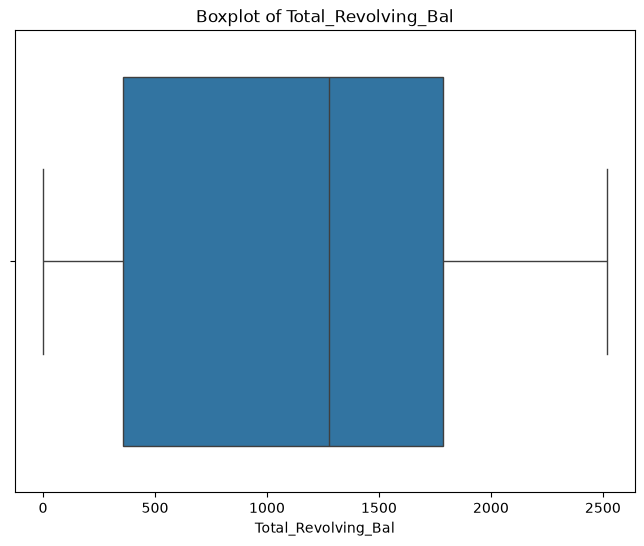

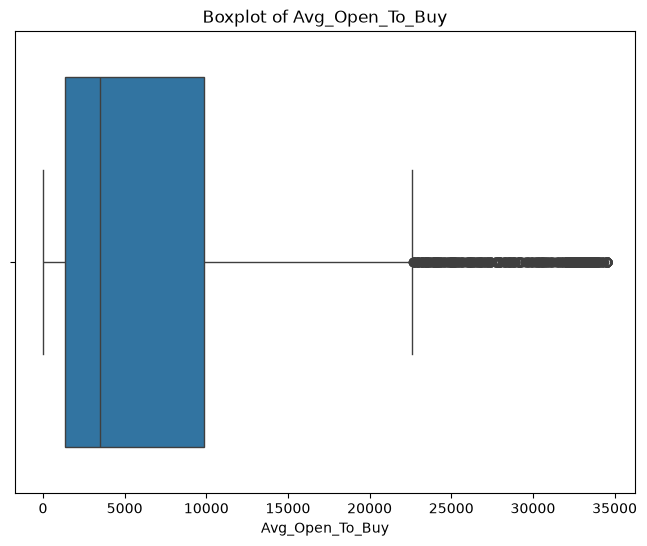

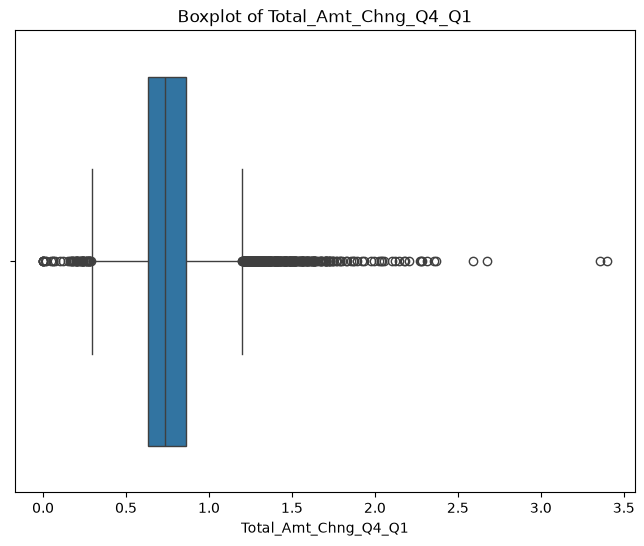

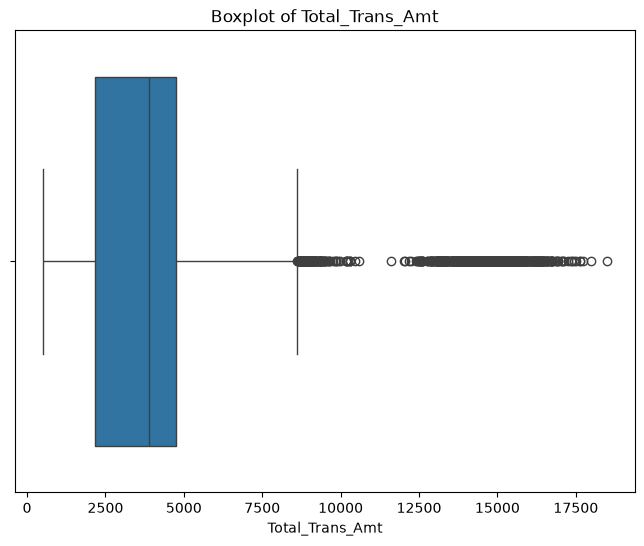

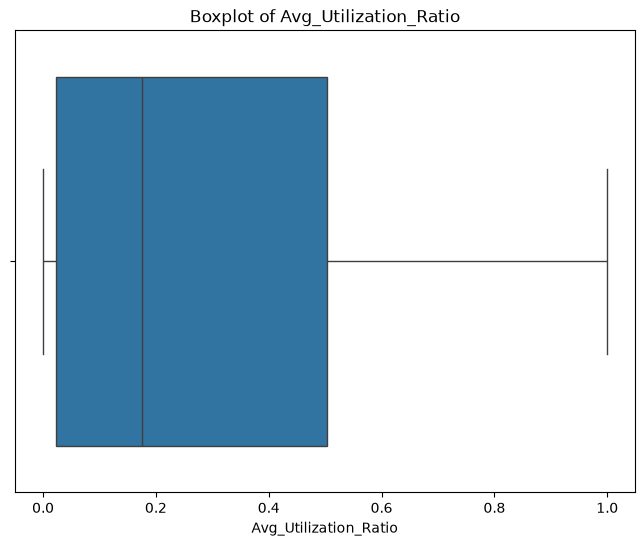

In [13]:
for column in num_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=data[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

The boxplots summarize the distribution of each numerical feature. The center line shows the median, the box covers the middle 50% of values, and points beyond the whiskers indicate potential outliers. These outliers should be investigated rather than removed automatically.

# **BIVARIATE ANALYSIS**

“Bi” means two. Bivariate analysis studies the relationship between two variables.
Purpose:

-Discover relationships between variables
-Compare customers who churned with those who stayed
-Identify factors that may influence churn
-Find useful features for machine-learning prediction


The bivariate plots below compare customer characteristics with `Attrition_Flag`. Differences between the existing and attrited groups provide exploratory evidence of possible predictors, but they should not be treated as proof of causation.

In [14]:
plt.figure(figsize=(8,6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

The age boxplot compares the age distributions of existing and attrited customers. Similar medians suggest age alone may be a weak separator, while a clear shift or different spread would indicate that age may contribute useful information when combined with other features.

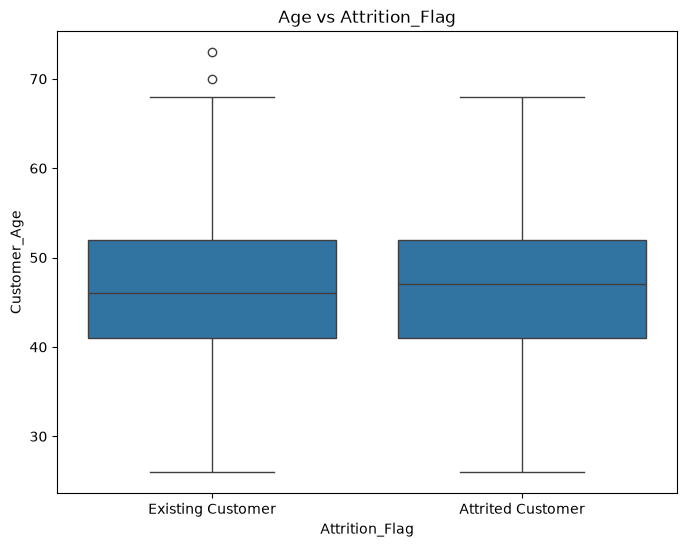

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=data)
plt.title('Age vs Attrition_Flag')
plt.xlabel('Attrition_Flag')
plt.ylabel('Customer_Age')
plt.show()

This chart compares the proportion of attrited customers within each gender rather than comparing raw customer counts. A higher bar indicates a higher observed churn rate for that group, but the difference should be checked for practical size and statistical reliability.

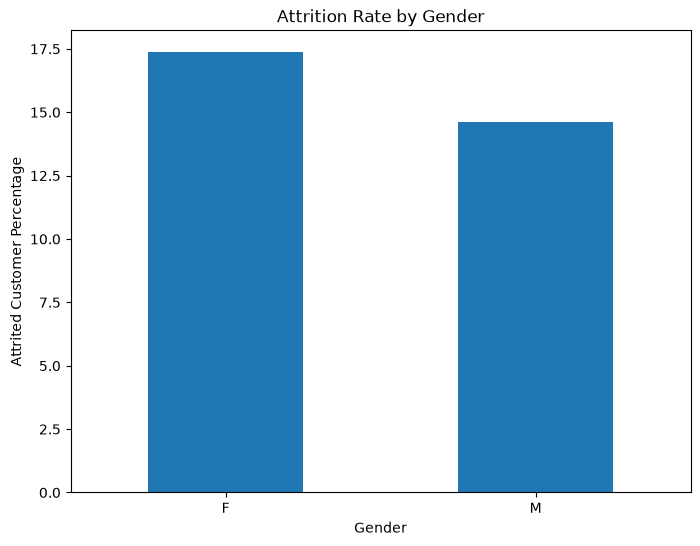

In [16]:
gender_attrition = data.groupby('Gender')['Attrition_Flag'].value_counts(normalize=True).unstack()
gender_attrition['Attrited Customer Percentage'] = gender_attrition['Attrited Customer'] * 100
gender_attrition= gender_attrition.sort_values(by='Attrited Customer Percentage', ascending=False)

#creating a bar plot to visualize the attrition
plt.figure(figsize=(8,6))
gender_attrition['Attrited Customer Percentage'].plot(kind='bar')
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrited Customer Percentage')
plt.xticks(rotation=0)
plt.show()

The income-level chart reports the percentage of customers who churned within each income category. Compare categories by rate, not by bar height alone, because income groups may contain different numbers of customers.

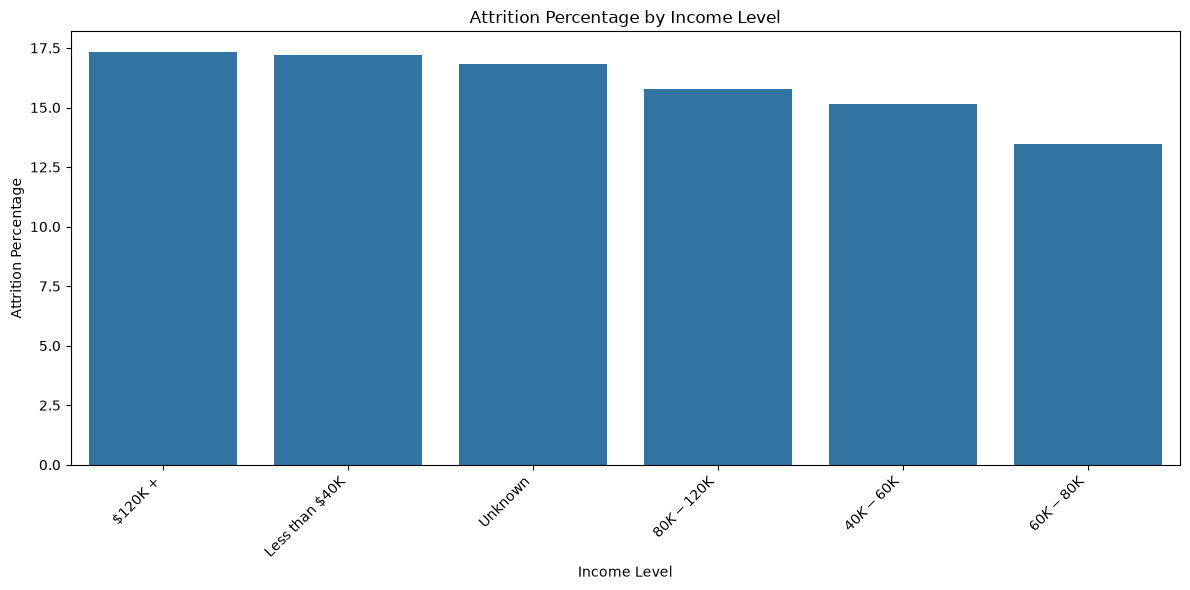

In [17]:
# Calculate the percentage of attrited customers for each income level
income_churn_counts = data.groupby(['Income_Category', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
income_churn_percentage = (income_churn_counts['Attrited Customer'] / (income_churn_counts['Attrited Customer'] + income_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': income_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The transaction-amount boxplot tests whether spending differs between existing and attrited customers. Lower transaction activity among attrited customers would be a useful warning signal, but overlapping boxes mean transaction amount should be combined with other behavioral variables.

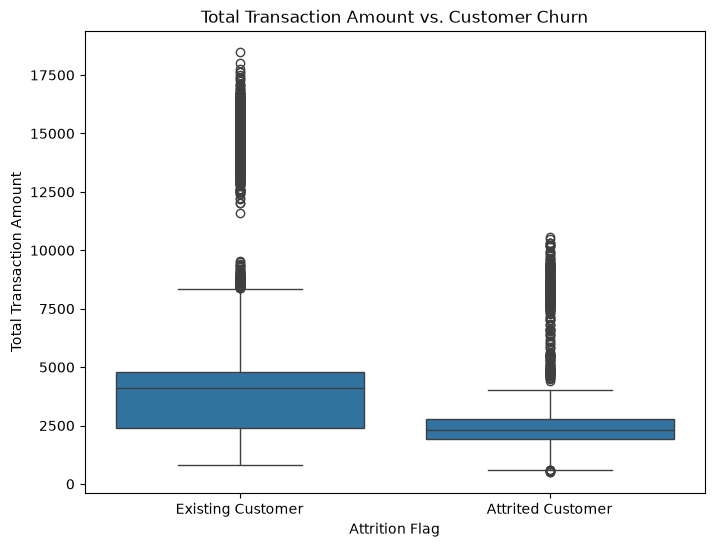

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=data)
plt.title('Total Transaction Amount vs. Customer Churn')
plt.xlabel('Attrition Flag')
plt.ylabel('Total Transaction Amount')
plt.show()

The education-level chart compares churn rates across education groups. Treat any differences as associations in this dataset; education may also be related to income, card usage, or other variables that jointly explain the observed pattern.

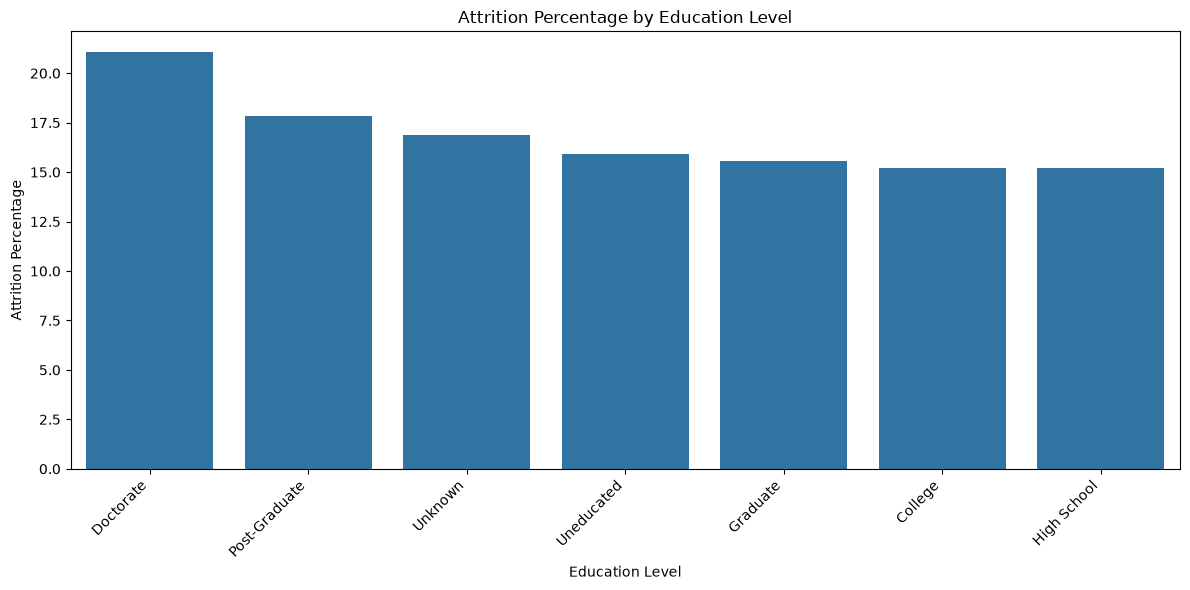

In [19]:
# Calculate the percentage of attrited customers for each education level
education_churn_counts = data.groupby(['Education_Level', 'Attrition_Flag'])['CLIENTNUM'].count().unstack()
education_churn_percentage = (education_churn_counts['Attrited Customer'] / (education_churn_counts['Attrited Customer'] + education_churn_counts['Existing Customer'])) * 100

# Create a DataFrame for the result and sort by percentage
churn_percentage_df = pd.DataFrame({'Percentage': education_churn_percentage}).sort_values('Percentage', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x=churn_percentage_df.index, y='Percentage', data=churn_percentage_df)
plt.title('Attrition Percentage by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The stacked bars show the composition of existing and attrited customers within each card category. A category with a larger attrited segment has a higher observed churn proportion, while a very small category should be interpreted cautiously.

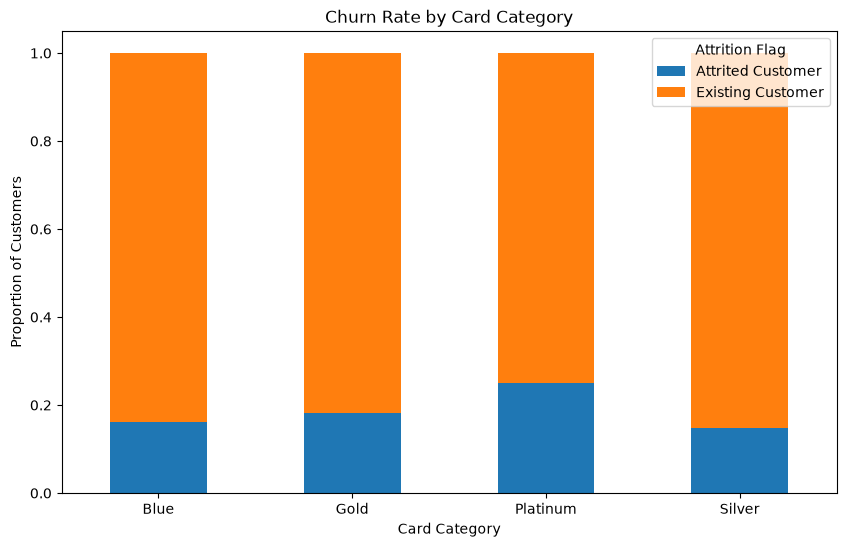

In [20]:
# Calculate the churn rate for each card category
churn_rates = data.groupby('Card_Category')['Attrition_Flag'].value_counts(normalize=True).unstack()

# Create the stacked bar chart
churn_rates.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn Rate by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.legend(title='Attrition Flag')
plt.show()

This countplot compares the number of existing and attrited customers at each inactivity level. If the attrited group becomes more common as inactivity increases, inactivity may be a useful churn-risk indicator; remember that the plot shows counts, not normalized rates.

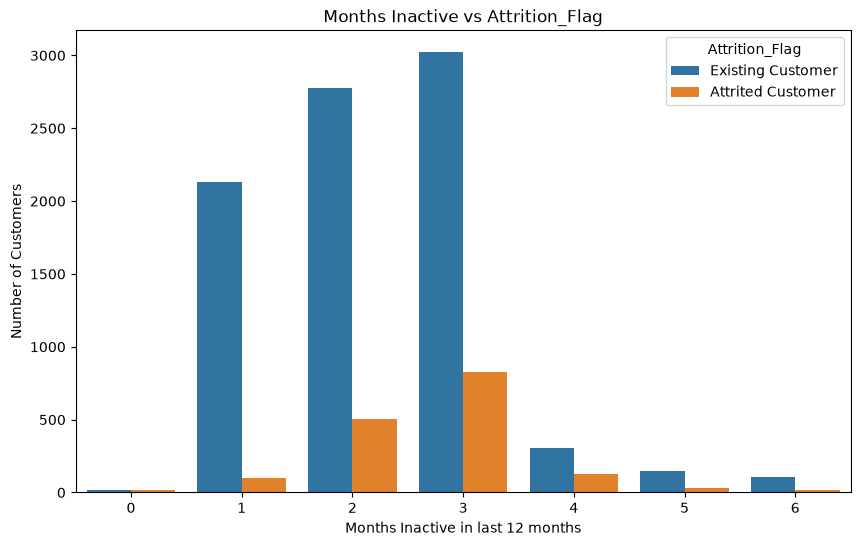

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='Months_Inactive_12_mon', hue='Attrition_Flag', data=data)
plt.title('Months Inactive vs Attrition_Flag')
plt.xlabel('Months Inactive in last 12 months')
plt.ylabel('Number of Customers')
plt.show()

The credit-limit boxplot compares account limits for existing and attrited customers. Differences in median or spread can reveal a relationship with churn, but substantial overlap means credit limit alone is unlikely to classify every customer correctly.

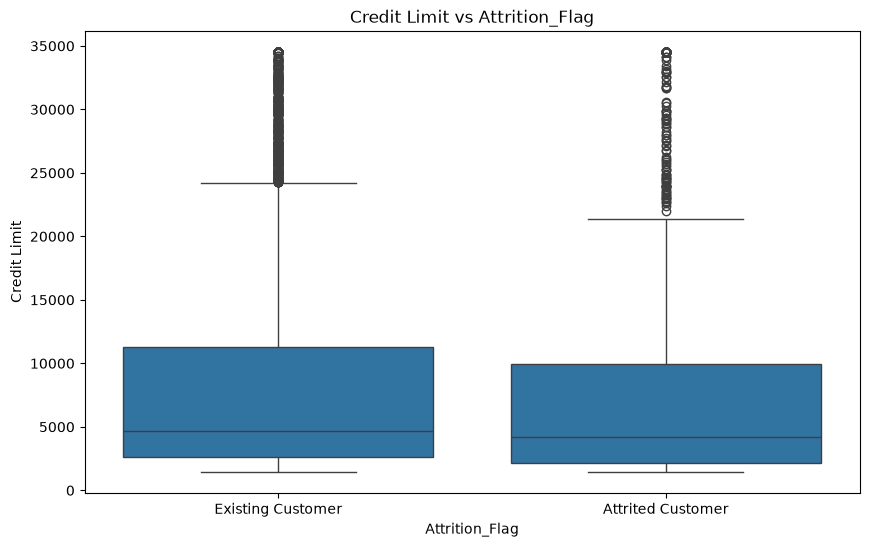

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=data)
plt.title('Credit Limit vs Attrition_Flag')
plt.xlabel('Attrition_Flag')
plt.ylabel('Credit Limit')
plt.show()

Preprocessing converts the raw columns into a consistent numerical representation. The target is separated from the predictors, identifiers are removed, categorical values are encoded, and the resulting data can then be supplied to scikit-learn classifiers.

Preprocessing is the process of preparing raw data so that a machine-learning model can understand and use it correctly.


## **ENCODING FOR CATRGORICAL VARIABLES**

CLIENTNUM is only an identification number. It does not help predict churn, so it is removed.

In [23]:
data = data.drop(['CLIENTNUM'], axis=1)

execute again the file that you imported and then execute this attrition flag

In [24]:
data['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Encoding the target variable

In [25]:
#create a mapping for the Attrition_Flag column
attrition_mapping = {'Existing Customer': 0, 'Attrited Customer': 1}

#use the mapping to convert the Attrition_Flag column to numerical values
data['Attrition_Flag'] = data['Attrition_Flag'].map(attrition_mapping)

In [26]:
data.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='str')

After dropping the identifier and encoding the target, inspect the column list to confirm that the target remains present and that no unintended columns were removed.

In [27]:
data['Education_Level'].unique()

<StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str

The unique values confirm the categories that must be represented numerically. The education mapping preserves an ordered progression from lower to higher education, while `Unknown` is assigned a separate code rather than being silently discarded.

In [28]:
education_mapping = {
    'Uneducated': 1,
    'High School': 2,
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6,
    'Unknown': 0
}
data['Education_Level'] = data['Education_Level'].map(education_mapping)

The mapping replaces education labels with numeric values so the feature can be used by the models. Because the values represent an ordered education level, the assigned numbers carry ordinal meaning; the unknown category remains distinct.

In [29]:
data['Income_Category'].unique()

<StringArray>
[   '$60K - $80K', 'Less than $40K',   '$80K - $120K',    '$40K - $60K',
        '$120K +',        'Unknown']
Length: 6, dtype: str

The unique income labels are reviewed before encoding so every category is covered by the mapping. The ordered codes represent increasing income bands, while `Unknown` is retained as its own category.

In [30]:
income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 0

}

data['Income_Category'] = data['Income_Category'].map(income_mapping)

One-hot encoding creates indicator columns for categorical values such as marital status and card category. `drop_first=True` removes one reference category per feature, which avoids redundant columns while retaining the information needed by the model.

In [31]:
data=pd.get_dummies(data, columns=['Marital_Status' , 'Card_Category'], drop_first=True,dtype=int)

In [32]:
data.head(10)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,M,3,2,3,39,5,1,3,...,1144,42,1.625,0.061,1,0,0,0,0,0
1,0,49,F,5,4,1,44,6,1,2,...,1291,33,3.714,0.105,0,1,0,0,0,0
2,0,51,M,3,4,4,36,4,1,0,...,1887,20,2.333,0.000,1,0,0,0,0,0
3,0,40,F,4,2,1,34,3,4,1,...,1171,20,2.333,0.760,0,0,1,0,0,0
4,0,40,M,3,1,3,21,5,1,0,...,816,28,2.500,0.000,1,0,0,0,0,0
5,0,44,M,2,4,2,36,3,1,2,...,1088,24,0.846,0.311,1,0,0,0,0,0
6,0,51,M,4,0,5,46,6,1,3,...,1330,31,0.722,0.066,1,0,0,1,0,0
7,0,32,M,0,2,3,27,2,2,2,...,1538,36,0.714,0.048,0,0,1,0,0,1
8,0,37,M,3,1,3,36,5,2,0,...,1350,24,1.182,0.113,0,1,0,0,0,0
9,0,48,M,2,4,4,36,6,3,3,...,1441,32,0.882,0.144,0,1,0,0,0,0


The preview verifies the transformed DataFrame after encoding marital status and card category. New indicator columns should contain 0/1 values, and the original text columns should no longer be present.

In [33]:
data=pd.get_dummies(data, columns=['Gender'], drop_first=True,dtype=int)

Gender has now been converted into a binary indicator column. The preview is a final preprocessing check that the feature matrix contains numeric values suitable for train-test splitting and model fitting.

In [34]:
data.head(10)

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Gender_M
0,0,45,3,2,3,39,5,1,3,12691.0,...,42,1.625,0.061,1,0,0,0,0,0,1
1,0,49,5,4,1,44,6,1,2,8256.0,...,33,3.714,0.105,0,1,0,0,0,0,0
2,0,51,3,4,4,36,4,1,0,3418.0,...,20,2.333,0.000,1,0,0,0,0,0,1
3,0,40,4,2,1,34,3,4,1,3313.0,...,20,2.333,0.760,0,0,1,0,0,0,0
4,0,40,3,1,3,21,5,1,0,4716.0,...,28,2.500,0.000,1,0,0,0,0,0,1
5,0,44,2,4,2,36,3,1,2,4010.0,...,24,0.846,0.311,1,0,0,0,0,0,1
6,0,51,4,0,5,46,6,1,3,34516.0,...,31,0.722,0.066,1,0,0,1,0,0,1
7,0,32,0,2,3,27,2,2,2,29081.0,...,36,0.714,0.048,0,0,1,0,0,1,1
8,0,37,3,1,3,36,5,2,0,22352.0,...,24,1.182,0.113,0,1,0,0,0,0,1
9,0,48,2,4,4,36,6,3,3,11656.0,...,32,0.882,0.144,0,1,0,0,0,0,1


## **TRAIN TEST SPLIT**

The data is divided into:

Training data: used to teach the model
Testing data: used to evaluate how well the model works on unseen data

-stratify=y keeps the same proportion of existing and attrited customers in both sets.

In [35]:
data['Attrition_Flag'].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

stratify means , if the values is imbalanced we should give to the model equally proportioned 0s an 1s, so we can use Straitify=y

1-Define the target variable
y is what the model must predict:

0 = Existing Customer
1 = Attrited Customer

2-Define the input features
X contains customer information such as age, income, credit limit, transactions, and inactivity.

3-Split the data
80% is used for training
20% is used for testing
stratify=y keeps the churn proportion balanced in both sets




In [36]:
y = data['Attrition_Flag']
X = data.drop('Attrition_Flag', axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training set shape: (8101, 23)
Test set shape: (2026, 23)
y_train shape: (8101,)
y_test shape: (2026,)


The model comparison table will store training and testing metrics for every classifier. Comparing both sets helps reveal overfitting: a very strong training score with a noticeably weaker testing score indicates poor generalization.

In [37]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_f1', 
                                           'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_f1'])

~
When y is continuous we use linear regression if its categorical we use desicion tree algorithm-random forest which it builds multiple trees and takes random variable,gradient Boosting which it builds  multiple trees sequentially and also boosting the trees means it will learn and minimize the error through squential
~
Desicion tree algorithm is useful to solve for regression also classification alos the output is in the form of tree
~
Linear regression algorithm is only be used when the target variable is continuos ,can be used when these type of regression problems

# **MODEL BUILDING**

Model building is the stage where we train machine-learning algorithms to predict whether a customer will leave the bank.

## **MODEL 1**

The first model is a decision tree classifier. It learns a sequence of feature-based rules and assigns each customer to an existing or attrited class at a terminal leaf.

In [38]:
#Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

#Train the model
dt_model.fit(x_train, y_train)

#make predictions on the training and testing data
y_dt_train_pred = dt_model.predict(x_train)
y_dt_test_pred = dt_model.predict(x_test)

#Evaluate the model on training data
dt_train_accuracy = accuracy_score(y_train, y_dt_train_pred)
dt_train_precision = precision_score(y_train, y_dt_train_pred)
dt_train_recall = recall_score(y_train, y_dt_train_pred)
dt_train_f1 = f1_score(y_train, y_dt_train_pred)

#Evaluate the model on testing data
dt_test_accuracy = accuracy_score(y_test, y_dt_test_pred)
dt_test_precision = precision_score(y_test, y_dt_test_pred)
dt_test_recall = recall_score(y_test, y_dt_test_pred)
dt_test_f1 = f1_score(y_test, y_dt_test_pred)

#Store the reults in model_eval_results DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Decision Tree', dt_train_accuracy, dt_train_precision, dt_train_recall, dt_train_f1,
                                                  dt_test_accuracy, dt_test_precision, dt_test_recall, dt_test_f1]


print("Model Evaluation Results:")
print(model_eval_results)



Model Evaluation Results:
           Model  Train_Accuracy  Train_Precision  Train_Recall  Train_f1  \
0  Decision Tree             1.0              1.0           1.0       1.0   

   Test_Accuracy  Test_Precision  Test_Recall   Test_f1  
0        0.94077        0.827476     0.796923  0.811912  


The decision tree results should be evaluated on the test set first. High training scores combined with lower test scores suggest that the unrestricted tree has memorized training examples and may need pruning or depth limits.

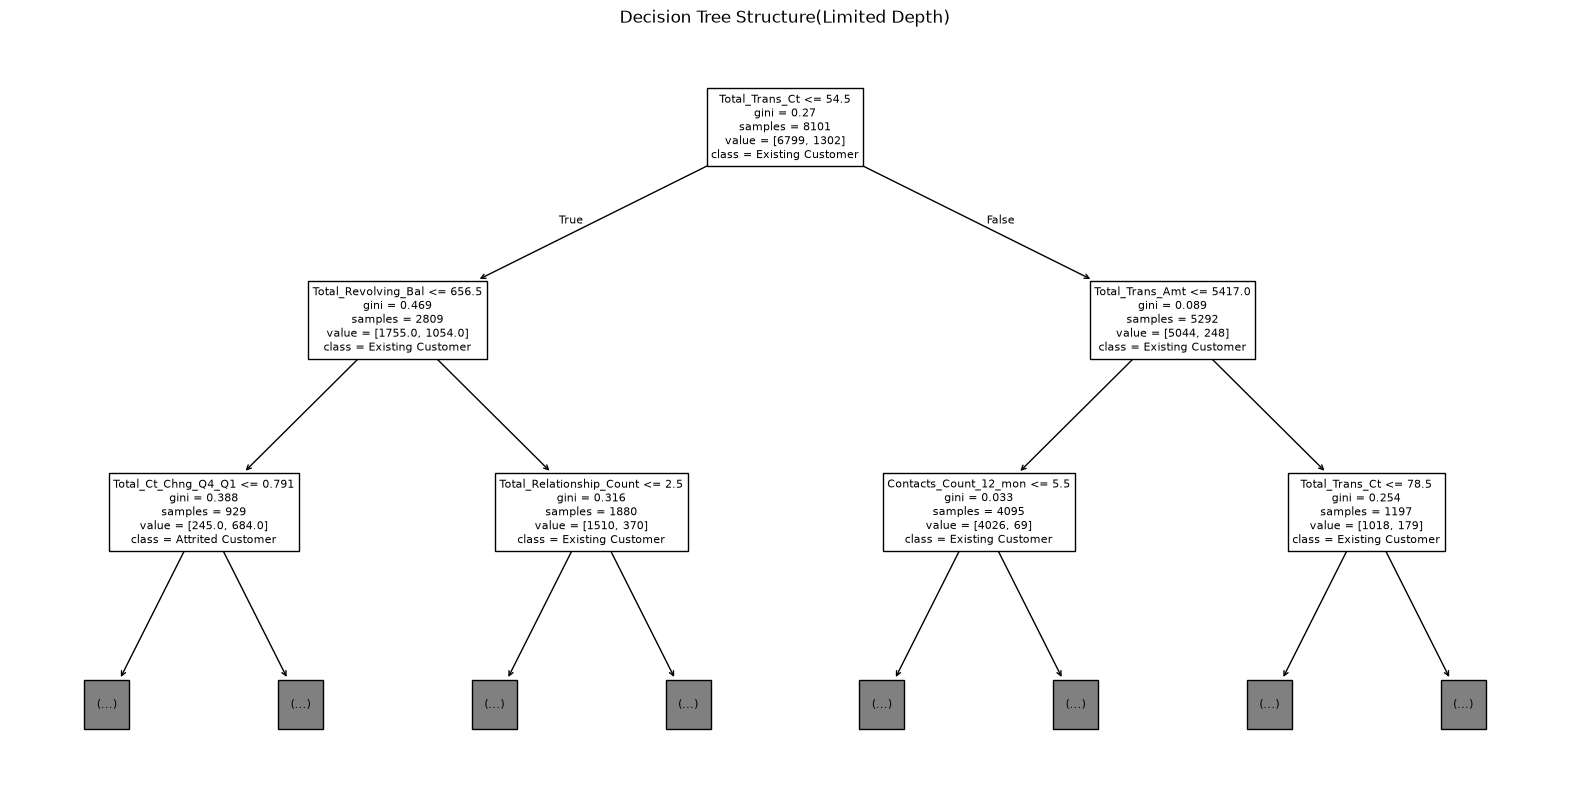

In [39]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Decision Tree Structure(Limited Depth)")
plt.show()

The plotted tree is limited to depth 2 so its first decisions can be read easily. The split features show which variables are used near the root, but this simplified view does not display the complete tree used for prediction.

## **MODEL 2**

The second model is a random forest classifier. It combines many decision trees trained with randomized samples and feature selections, which usually produces a more stable prediction than one unrestricted tree.

In [40]:
rf_model= RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)

rf_y_train_pred = rf_model.predict(x_train)
rf_y_test_pred = rf_model.predict(x_test)

#Evaluate the model on training data
rf_train_accuracy = accuracy_score(y_train, rf_y_train_pred)
rf_train_precision = precision_score(y_train, rf_y_train_pred)
rf_train_recall = recall_score(y_train, rf_y_train_pred)
rf_train_f1 = f1_score(y_train, rf_y_train_pred)

#Evaluate the model on testing data
rf_test_accuracy = accuracy_score(y_test, rf_y_test_pred)
rf_test_precision = precision_score(y_test, rf_y_test_pred)
rf_test_recall = recall_score(y_test, rf_y_test_pred)
rf_test_f1 = f1_score(y_test, rf_y_test_pred)

#Store the reults in model_eval_results DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Random Forest', rf_train_accuracy, rf_train_precision, rf_train_recall, rf_train_f1,
                                                  rf_test_accuracy, rf_test_precision, rf_test_recall, rf_test_f1]


print("Model Evaluation Results:")
print(model_eval_results)







Model Evaluation Results:
           Model  Train_Accuracy  Train_Precision  Train_Recall  Train_f1  \
0  Decision Tree             1.0              1.0           1.0       1.0   
1  Random Forest             1.0              1.0           1.0       1.0   

   Test_Accuracy  Test_Precision  Test_Recall   Test_f1  
0       0.940770        0.827476     0.796923  0.811912  
1       0.956565        0.937269     0.781538  0.852349  


Compare the random forest training and testing metrics. A smaller gap between the two sets indicates better generalization, while the test recall is especially important when the business wants to identify as many potential churners as possible.

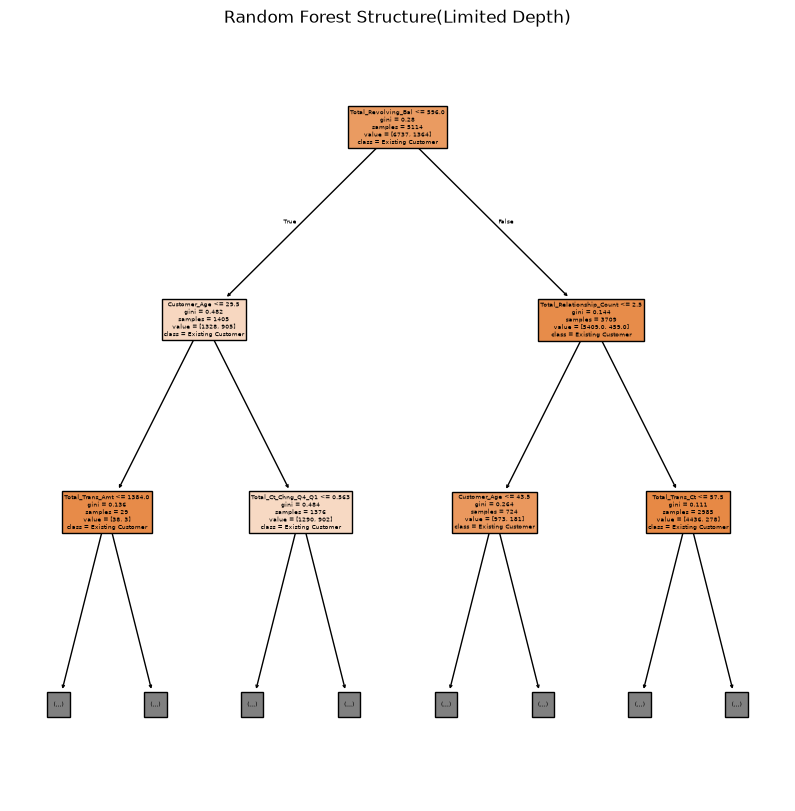

In [41]:
plt.figure(figsize=(10,10))
plot_tree(rf_model.estimators_[0],filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Random Forest Structure(Limited Depth)")
plt.show()

The displayed tree is only the first estimator from the forest and is limited to depth 2 for readability. The random forest prediction comes from the combined vote of all estimators, not from this single plotted tree.

## **MODEL 3**

The third model is gradient boosting. It builds shallow trees sequentially, with each new tree focusing on errors made by the earlier trees, so the ensemble gradually improves its classification boundary.

In [42]:
gb= GradientBoostingClassifier(random_state=42)

gb.fit(x_train, y_train)

gb_y_train_pred = gb.predict(x_train)
gb_y_test_pred = gb.predict(x_test) 

#Evaluate the model on training data
gb_train_accuracy = accuracy_score(y_train, gb_y_train_pred)
gb_train_precision = precision_score(y_train, gb_y_train_pred)
gb_train_recall = recall_score(y_train, gb_y_train_pred)
gb_train_f1 = f1_score(y_train, gb_y_train_pred)

#Evaluate the model on testing data
gb_test_accuracy = accuracy_score(y_test, gb_y_test_pred)
gb_test_precision = precision_score(y_test, gb_y_test_pred)
gb_test_recall = recall_score(y_test, gb_y_test_pred)
gb_test_f1 = f1_score(y_test, gb_y_test_pred)

#Store the reults in model_eval_results DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Gradient Boosting', gb_train_accuracy, gb_train_precision, gb_train_recall, gb_train_f1,
                                                  gb_test_accuracy, gb_test_precision, gb_test_recall, gb_test_f1]

print("Model Evaluation Results:")
print(model_eval_results)

Model Evaluation Results:
               Model  Train_Accuracy  Train_Precision  Train_Recall  Train_f1  \
0      Decision Tree        1.000000         1.000000      1.000000  1.000000   
1      Random Forest        1.000000         1.000000      1.000000  1.000000   
2  Gradient Boosting        0.975559         0.953202      0.891705  0.921429   

   Test_Accuracy  Test_Precision  Test_Recall   Test_f1  
0       0.940770        0.827476     0.796923  0.811912  
1       0.956565        0.937269     0.781538  0.852349  
2       0.963968        0.956522     0.812308  0.878536  


Gradient boosting should be judged using the held-out test metrics rather than training performance alone. The preferred model is the one that balances test recall, precision, F1-score, and accuracy for the bank's retention objective.

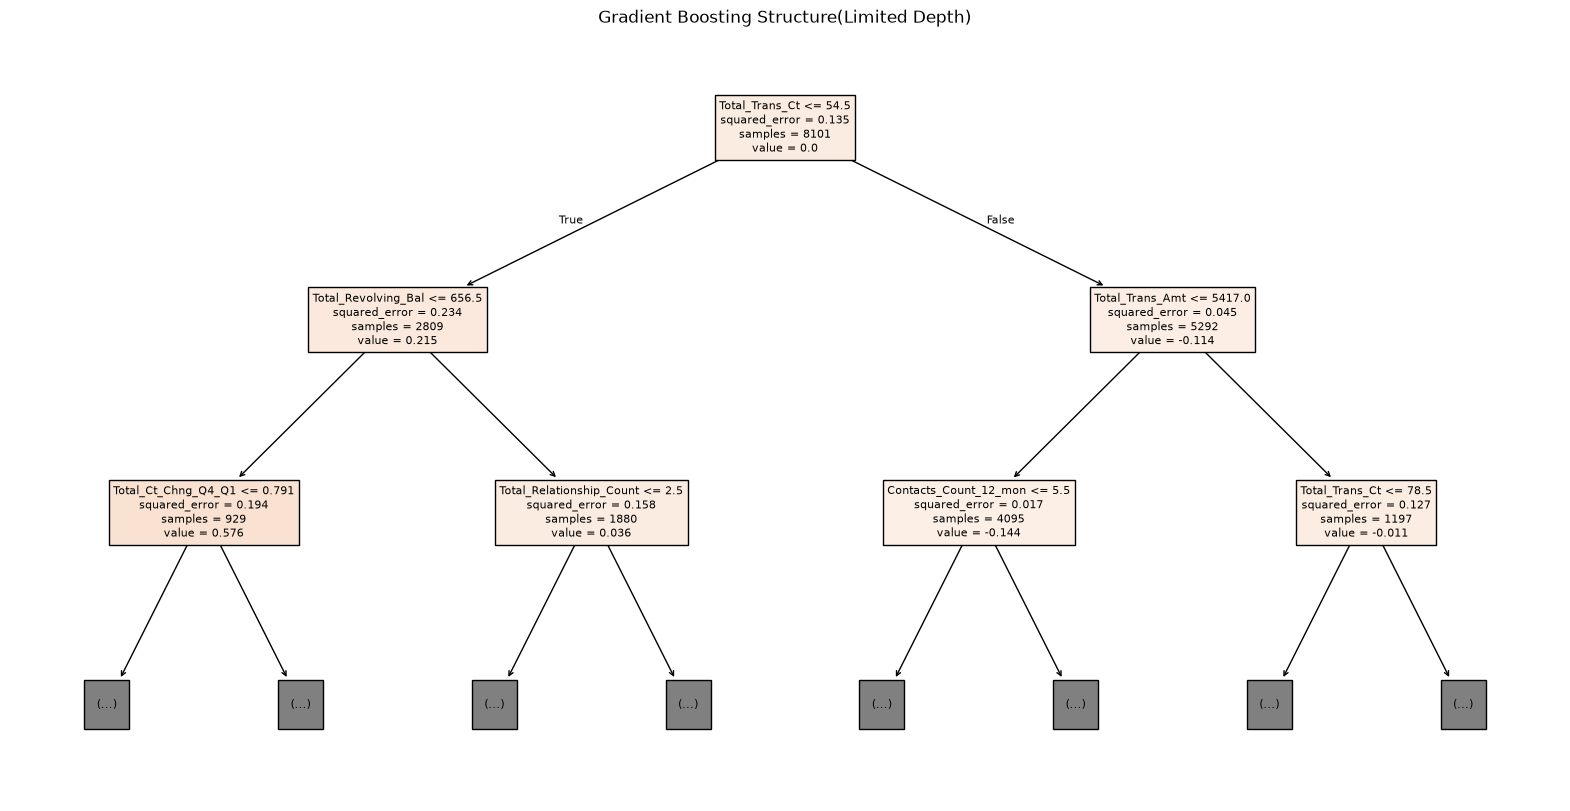

In [43]:
plt.figure(figsize=(20,10))
plot_tree(gb.estimators_[0, 0],filled=True, feature_names=X.columns, class_names=['Existing Customer', 'Attrited Customer'], max_depth=2)
plt.title("Gradient Boosting Structure(Limited Depth)") 
plt.show()

The plotted boosting tree is the first weak learner and is limited to depth 2 for interpretation. The final gradient boosting model combines many sequential trees, so this diagram explains the model structure but does not represent the full ensemble.

# *Model Comparison & Final Model Selection*

In [44]:
model_eval_results

,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_f1,Test_Accuracy,Test_Precision,Test_Recall,Test_f1
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,0.940770,0.827476,0.796923,0.811912
1,Random Forest,1.000000,1.000000,1.000000,1.000000,0.956565,0.937269,0.781538,0.852349
2,Gradient Boosting,0.975559,0.953202,0.891705,0.921429,0.963968,0.956522,0.812308,0.878536


## *Final Model Selection: Gradient Boosting*

**Gradient Boosting is the best model for this churn-prediction task.** It achieves the strongest results on the held-out test set:

- **Accuracy:** 0.964
- **Precision:** 0.957
- **Recall:** 0.812
- **F1-score:** 0.879

It outperforms the Decision Tree and Random Forest on every test metric. Its test F1-score is the highest, showing the best balance between correctly identifying customers who will churn and avoiding unnecessary retention actions. It also has the smallest train-test performance gap, which indicates better generalization and less overfitting than the two other models.

The **Gradient Boosting model should therefore be selected for deployment**. Recall remains important because missed churners represent lost retention opportunities, while the high precision helps ensure that retention resources are focused on customers who are genuinely likely to leave. Before production use, the model should be validated with cross-validation and monitored after deployment.